[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/SH2026_workshop.ipynb)

# AI and NLP for Spatial Humanities

**Spatial Humanities 2026 · University of Minho, Braga · Wednesday 23 September, 09:30–12:30**

Ignatius Ezeani, Paul Rayson, Ian Gregory · UCREL, Lancaster University

<p align="center">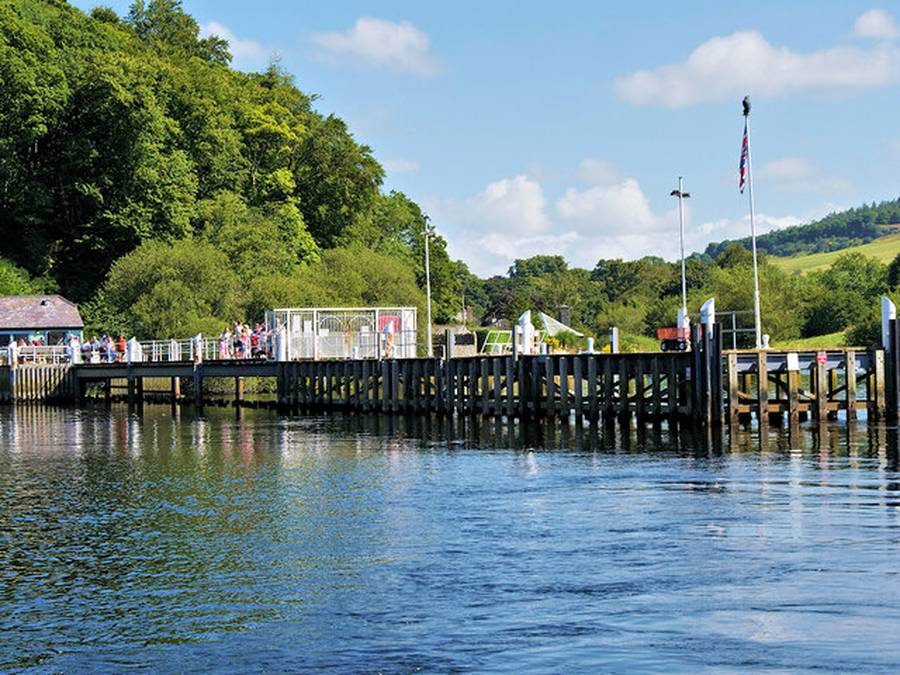</p>

<p align="center"><em>Ullswater. The Lake District has been written about continuously since 1622, and this workshop uses 28 of those texts.<br>Photograph: David Dixon / Geograph, CC BY-SA 2.0</em></p>

---

### What you will do

Annotate a passage of eighteenth-century travel writing by hand, then watch six
automatic systems attempt the same thing, and work out where they disagree and
which of them you would defend in print.

### What you need

A browser. No API key, no GPU, no paid account, no prior Python.

### The five blocks

| | | |
|---|---|---|
| 09:30 | Setup and framing | 15 min |
| 09:45 | Annotate it yourself | 35 min |
| 10:20 | Rules, gazetteers, and what they cannot see | 35 min |
| 10:55 | **Break** | 15 min |
| 11:10 | Six systems, one passage | 35 min |
| 11:45 | Evidence-first extraction | 30 min |
| 12:15 | From text to map, and what not to map | 15 min |

### Five more notebooks are yours afterwards

We will not reach `04` linking, `05` affect, `07` adjudication, the rest of `08`,
or most of `09` today. They are in this repository with **all outputs committed**,
so you can work through them alone. I will point at each one as we pass it.

---

# Block 0. Setup and framing

`09:30` · 15 minutes

**What this does.** Downloads the workshop code and installs it. Once, for the whole session.

**Why it matters.** Everything after this is about scholarship rather than software. This is the only cell that touches the internet for setup.

**What you should see.** A short report ending in `route : CPU only, no API key needed`. About 90 seconds.

**If it fails, put your hand up.** Do not run it a second time: that will not help and it slows the room's connection.

In [ ]:
!wget -q https://raw.githubusercontent.com/IgnatiusEzeani/spatial-humanities-2026/sh2026-workshop/workshop/sh2026_setup.py

import sh2026_setup as sh
ctx = sh.setup()

from workshop_support.display import (show_spans, compare_spans, show_journey,
                                      show_fields, checkpoint)
import json, pandas as pd

PASSAGES = {p["passage_id"]: p for p in
             json.load(open(ctx.data / "workshop_passages.json"))}
PANEL = json.load(open(ctx.data / "panel_cache.json"))
print(f"{len(PASSAGES)} passages loaded, with the human gold standard attached.")

**What this does.** Checks that everything the morning needs actually arrived.

**Why it matters.** The cell above can finish without error and still leave something missing. Better to find out now, with fifteen minutes in hand, than at half past eleven.

**What you should see.** Six lines, all saying OK. If any says MISSING, put your hand up: it is a two-minute fix now and a lost block later.

In [ ]:
import importlib

NEEDED = {
    "spatio_textual":            "the annotation library",
    "spatio_textual.journeys":   "journey extraction, Block 4",
    "workshop_support.display":  "highlighted text, every block",
    "workshop_support.clients":  "the teaching models, Block 4",
    "spacy":                     "the NER pipeline, Block 3",
    "ipywidgets":                "the annotation widget, Block 1",
}

missing = []
for module, why in NEEDED.items():
    try:
        importlib.import_module(module)
        print(f"  OK       {module:28s} {why}")
    except Exception as exc:
        missing.append(module)
        print(f"  MISSING  {module:28s} {why}")
        print(f"           -> {type(exc).__name__}: {exc}")

if missing:
    print()
    print(f"  {len(missing)} missing. Put your hand up.")
    print("  Blocks 1 to 3 still work without spatio_textual;"
          " only Block 4 needs it.")
else:
    print()
    print("  Everything is here. Nothing else in this notebook"
          " touches the internet.")

## What this workshop is about

Here is a sentence from a guide to the English Lakes, published in 1859.

> From Penrith two roads lead to Pooley Bridge, about six miles distant, which
> spans the Eamont just at its issue from Ulleswater.

A geoparser will return four things from it: `Penrith`, `Pooley Bridge`,
`Eamont`, `Ulleswater`. Four strings, four dots on a map.

The sentence also tells you that two roads connect the first two places, that the
distance is *about* six miles and therefore narrated rather than measured, that
one water issues from another, and that somebody travelled this way. None of that
is a name, and all of it is geography.

**The question for the next three hours: what can we claim about a passage, and
what evidence allows us to claim it?**

**What this does.** Shows the three layers of spatial meaning this workshop distinguishes.

**Why it matters.** Only the first has coordinates. Most tools only do the first. Most humanities questions need the other two.

**What you should see.** A three-row table. Read the examples column rather than the definitions.

In [ ]:
layers = pd.DataFrame([
    {"layer": "Location",
     "definition": "Named places that may carry a coordinate",
     "example": "Penrith, Keswick, Auschwitz-Birkenau"},
    {"layer": "Locale",
     "definition": "Geographical and social settings, usually common nouns",
     "example": "hill, lake, road, inn, camp, station"},
    {"layer": "Sense of place",
     "definition": "How a place was experienced, and by whom",
     "example": "picturesque, wild, \u201cvery cold\u201d, relief"},
])
display(layers)

<table><tr><td width="230">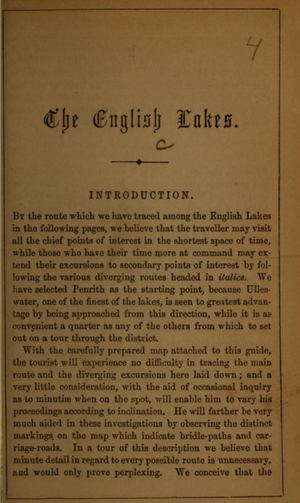</td><td>

### Today's sources are real

Every passage in this notebook comes from the **Corpus of Lake District Writing**:
80 manually digitised texts, 1622 to 1900, about 1.5 million words. Twenty-eight
of them carry a **human gold standard** of place-name annotation, which is what
you will be compared against.

Here is the passage you will annotate. Arthur Young, *Six Months' Tour Through the
North of England*, 1770.

> Returning to Penrith, I took the road to Shapp, by Lowther Hall, the ſeat of Sir James Lowther, Bart.

Note `ſeat`. That is a long s, U+017F, standard in eighteenth-century printing and
a genuine difficulty for modern tools. We will come back to it.

</td></tr></table>


In [ ]:
checkpoint("Setup complete. Everything from here runs locally.")

---

# Block 1. Annotate it yourself

`09:45` · 35 minutes

No models in this block. You are the annotator.

The reason to do this first is that every disagreement you have with the reference
annotation in ten minutes' time is a disagreement a model will also have, and you
will recognise it when you see it.

**What this does.** Displays the passage with nothing marked.

**Why it matters.** Before you can judge an automatic annotation you need a view of what a complete one would be.

**What you should see.** One sentence of 1770 prose, unmarked.

In [ ]:
rec = PASSAGES["ld80_long_18c_cf5aec5784"]
text = rec["text"]

print(f'{rec["author"]}, {rec["title"][:60]} ({rec["year_pub"]})\n')
show_spans(text, [], title="Unannotated")

### Exercise A: on paper, two minutes

Do not type anything yet. With the person next to you, decide:

1. Which stretches of this sentence are spatial?
2. For each, which of the three layers is it?
3. Where exactly does each one start and stop? Does `Lowther Hall` include
   `Hall`? Does `the road to Shapp` include `the road`?

The third question is where annotation projects actually spend their time.

**What this does.** Point-and-click annotation: choose the first and last word of each span, then a label.

**Why it matters.** You never type a phrase, so you never fight a typo. More to the point, picking an end word IS the boundary decision: does `Lowther Hall` include `Hall`? Answer it by choosing a different end word.

**What you should see.** Three dropdowns and three buttons. Your spans appear highlighted in the passage below them, and update as you add.

**Try changing this.** Mark three or four spans. Try `Lowther Hall` both ways and see which you would defend.

In [ ]:
from workshop_support.annotate import annotation_widget
from workshop_support.display import show_spans

annotator = annotation_widget(text, renderer=show_spans)

**What this does.** Reads your spans out of the widget.

**Why it matters.** The widget holds character offsets, not phrases, so nothing has to be located in the text again. This is the same representation the models produce, which is what makes the comparison later possible at all.

**What you should see.** A list of what you marked.

In [ ]:
participant_spans = annotator.spans

for s in participant_spans:
    print(f'  {s["text"]!r:28s} {s["label"]:9s} [{s["start_char"]}:{s["end_char"]}]')
if not participant_spans:
    print("  nothing marked yet. Use the widget above, then re-run this cell.")

> **If the widget does not appear**, Colab occasionally declines to render
> ipywidgets. Use the typed route instead, which does the same job:
>
> ```python
> from workshop_support.annotate import manual_annotation
> participant_spans = manual_annotation(text, [
>     ("Penrith", "TOPONYM"),
>     ("road",    "GEONOUN"),
> ])
> show_spans(text, participant_spans, title="Your annotation")
> ```

### Exercise B: predict before you look

Before revealing the reference, write down your answer to two questions.

1. How many spans do you think the reference annotator marked?
2. Name one span where you expect to disagree with them.

Hold on to the second answer. It is the interesting one.

**What this does.** Shows the human reference annotation beside yours.

**Why it matters.** The reference is a recorded scholarly judgement, not ground truth. Where you disagree, one of you made a decision the other did not.

**What you should see.** Two copies of the sentence. The reference marks place names only, which is itself a decision with consequences.

**Try changing this.** Set SHOW_REFERENCE to True only once you have finished Exercise A.

In [ ]:
SHOW_REFERENCE = False  # @param {type:"boolean"}

if SHOW_REFERENCE:
    reference = [{"start_char": g["start"], "end_char": g["end"],
                  "label": g["label"], "text": g["text"]} for g in rec["gold_spans"]]
    compare_spans(text, {"your annotation": participant_spans,
                         "human reference (CLDW gold standard)": reference})
else:
    print("Reference hidden. Finish your own annotation, then tick the box "
          "on the right and re-run.")

### What the reference does not contain

The gold standard marks `Penrith`, `Shapp`, `Lowther Hall`. It does **not** mark
`the road`, and it has no category for it.

That is not an oversight. The annotation scheme was built to answer questions
about *named places*, and it answers them very well. But it means this corpus, as
annotated, cannot tell you about roads, distances, directions or routes, because
those were never in the inventory.

**An annotation scheme is a theory about what matters.** Everything downstream,
including every number in the second half of this workshop, inherits it.

**What this does.** Scores your annotation against the reference two ways.

**Why it matters.** Exact match demands identical character offsets. Overlap match accepts any overlap. The gap between them is not model error: it is the cost of a boundary convention.

**What you should see.** Two numbers. The exact score will be lower, possibly much lower, even where you and the reference clearly meant the same place.

In [ ]:
def score(pred, ref, mode):
    used, tp = set(), 0
    for p in pred:
        for j, g in enumerate(ref):
            if j in used:
                continue
            if mode == "exact":
                hit = p["start_char"] == g["start_char"] and p["end_char"] == g["end_char"]
            else:
                hit = p["start_char"] < g["end_char"] and p["end_char"] > g["start_char"]
            if hit:
                used.add(j); tp += 1; break
    prec = tp / len(pred) if pred else 0.0
    rec_ = tp / len(ref) if ref else 0.0
    f1 = 2 * prec * rec_ / (prec + rec_) if prec + rec_ else 0.0
    return {"mode": mode, "precision": round(prec, 3),
            "recall": round(rec_, 3), "f1": round(f1, 3)}

ref = [{"start_char": g["start"], "end_char": g["end"],
        "label": g["label"], "text": g["text"]} for g in rec["gold_spans"]]
topo = [s for s in participant_spans if s["label"] == "TOPONYM"]
display(pd.DataFrame([score(topo, ref, "exact"), score(topo, ref, "overlap")]))

In [ ]:
checkpoint("You have annotated a real historical passage and disagreed with "
           "a real scholar. That disagreement is the subject of the rest of "
           "the morning.")

> **Self-study:** notebook [`01_manual_annotation`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/01_manual_annotation.ipynb) goes further into
> annotation policy, inter-annotator agreement, and relations between spans.

---

# Block 2. Rules, gazetteers, and what they cannot see

`10:20` · 35 minutes

The oldest method, and still the most transparent. A gazetteer is a list of
place names; a rule matcher marks every occurrence.

Its great virtue is that when it fails you can say exactly why.

**What this does.** Runs a small gazetteer over the passage.

**Why it matters.** Every hit is traceable to a line in a file you can open. No model, no probability, no ambiguity about cause.

**What you should see.** Some places found, some missed. The misses are the interesting part.

In [ ]:
GAZETTEER = {"Penrith": "TOPONYM", "Keswick": "TOPONYM", "Helvellyn": "TOPONYM",
             "Borrowdale": "TOPONYM", "Windermere": "TOPONYM",
             "road": "GEONOUN", "hall": "GEONOUN", "lake": "GEONOUN"}

import re
def gazetteer_annotate(t, gaz):
    out = []
    for surface in sorted(gaz, key=len, reverse=True):
        for m in re.finditer(rf"\b{re.escape(surface)}\b", t):
            if any(m.start() < s["end_char"] and m.end() > s["start_char"] for s in out):
                continue
            out.append({"start_char": m.start(), "end_char": m.end(),
                        "label": gaz[surface], "text": m.group()})
    return sorted(out, key=lambda s: s["start_char"])

show_spans(text, gazetteer_annotate(text, GAZETTEER), title="Rules + gazetteer")

### It missed `Shapp` and `Lowther Hall`

Not because the method is weak, but because those names are not in the list. That
is the whole story, and you can fix it by adding two lines.

Now watch a failure you cannot fix by adding a name.

**What this does.** Runs the same gazetteer over two sentences that differ by one letter.

**Why it matters.** `road` is in the gazetteer. `roads` is not. One inflected form absent from one list, and the geography of the sentence disappears.

**What you should see.** The first sentence is annotated. The second is not.

**Try changing this.** Add `"roads": "GEONOUN"` to GAZETTEER above and re-run both cells.

In [ ]:
for s in ["A road crossed the village.", "Two roads crossed the village."]:
    show_spans(s, gazetteer_annotate(s, GAZETTEER), title=s)

### Now the harder case: the long s

Eighteenth-century printing uses **ſ** (U+017F) where we write *s*. It is in
2,358 places in this corpus, plus another 7,415 encoded as an integral sign.

Here is Stebbing Shaw, 1788.

**What this does.** Runs the gazetteer over a passage in original eighteenth-century orthography.

**Why it matters.** `Keſwick` and `Keswick` are different strings. Every exact-match method in existence, including modern neural ones, has to deal with this.

**What you should see.** The gazetteer finds nothing, although the passage contains three place names and one of them is in your list.

In [ ]:
shaw = PASSAGES["ld80_long_18c_e0537eed45"]
print(shaw["text"], "\n")
print("gold standard marks:", [g["text"] for g in shaw["gold_spans"]], "\n")
show_spans(shaw["text"], gazetteer_annotate(shaw["text"], GAZETTEER),
           title="Rules + gazetteer on 1788 orthography")

### The decision this forces

You can normalise `ſ` to `s` before annotating. Everything gets easier, and you
have silently edited a historical source.

You can leave it, and accept that your tools will struggle.

Neither is wrong. But it is a **research decision**, not a preprocessing default,
and it changes what your results mean. We ran the whole experiment both ways for
exactly this reason.

> **Self-study:** notebook [`02_rules_and_gazetteers`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/02_rules_and_gazetteers.ipynb) has the full
> perturbation experiment; [`04_linking_and_ambiguity`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/04_linking_and_ambiguity.ipynb) covers `Cambridge`
> (which Cambridge?) and `Czechoslovakia` (a place that no longer exists, and why
> leaving it unresolved beats a confidently anachronistic coordinate).

In [ ]:
checkpoint("Rules are transparent and brittle. Both properties matter.")

---

## ☕ Break, 15 minutes

`10:55`

---

# Block 3. Six systems, one passage

`11:10` · 35 minutes

We ran six systems over 399 passages of this corpus, scored against 789
human-annotated place names.

You are about to see what they actually returned. These are real outputs from that
run, cached here so nothing needs an API key.

**What this does.** Shows six systems annotating the same passage, highlighted in the text.

**Why it matters.** A single F1 number tells you that methods differ. This tells you WHERE, and lets you judge whether the difference matters for your question.

**What you should see.** Six copies of the sentence. Note who finds `Lowther Hall`, who splits it, and who marks things the gold standard has no category for.

**Try changing this.** Pick a different passage from the dropdown and re-run. The 1788 one is in original orthography; one has no gold spans at all.

In [ ]:
PASSAGE = "Arthur Young, 1770  (3 gold)"  # @param ["Arthur Young, 1770  (3 gold)", "Anon.-Nelson (pub.), 1859  (5 gold)", "Stebbing Shaw, 1788  (3 gold)", "John Keats, 1883  (3 gold)", "Herbert Rix, 1893  (no gold spans)", "Anon.-Nelson (pub.), 1859  (2 gold)"]

CHOICES = {
    "Arthur Young, 1770  (3 gold)": "ld80_long_18c_cf5aec5784",
    "Anon.-Nelson (pub.), 1859  (5 gold)": "ld80_victorian_6a5160a116",
    "Stebbing Shaw, 1788  (3 gold)": "ld80_long_18c_e0537eed45",
    "John Keats, 1883  (3 gold)": "ld80_regency_romantic_4d879b98c6",
    "Herbert Rix, 1893  (no gold spans)": "ld80_victorian_512be44529",
    "Anon.-Nelson (pub.), 1859  (2 gold)": "ld80_victorian_387e1d9cef",
}

p = PASSAGES[CHOICES[PASSAGE]]
by_system = {k: v for k, v in PANEL[CHOICES[PASSAGE]].items()}
by_system["human reference"] = [
    {"start_char": g["start"], "end_char": g["end"], "label": g["label"],
     "text": g["text"]} for g in p["gold_spans"]]

compare_spans(p["text"], by_system)

### The ontology ceiling

Look at the last row. The reference marks place names. Some of the systems also
marked the road, the distance, the direction.

Those are not errors. They are annotations of layers the gold standard does not
contain, so when we score against it they count as **false positives**. Scored
naively, the systems doing the richer annotation look worse.

This is worth stating plainly, because it is the single most common way
evaluations mislead: **a benchmark measures what its annotation scheme contains,
and nothing else.**

**What this does.** Counts what each system emitted, by layer, across all 399 passages.

**Why it matters.** One of these systems has no category for anything except place names. Compare the last two columns.

**What you should see.** A six-row table. `hf_bert_ner` has zeros in four columns and cannot have anything else, because its label inventory has no room for them.

In [ ]:
display(pd.DataFrame(PANEL["_layer_counts"]).set_index("voter"))

**What this does.** The measured result: precision, recall and F1 against the human gold, with 95% confidence intervals, under both matching regimes.

**Why it matters.** Two things to read. First, the exact-to-overlap gap, which is the cost of boundary convention rather than failure to find places. Second, the intervals: where they overlap, there is no ranking to report.

**What you should see.** Frontier models around 0.79 to 0.81 exact. A pinned 2019 BERT at 0.70. And a latency column that spans three orders of magnitude.

In [ ]:
res = pd.DataFrame(PANEL["_results"])
display(res.style.format({"P": "{:.3f}", "R": "{:.3f}", "F1": "{:.3f}",
                          "ms/passage": "{:,.0f}"}))

### Read the last column before the first

`hf_bert_ner` scores 0.700 and takes **90 milliseconds** per passage.
`gemini_2_5` scores 0.805 and takes **22,670 milliseconds**.

That is 0.105 F1 for a 252-fold increase in time. Over 1.5 million words, the
first finishes in an afternoon and the second does not.

Which you should use depends entirely on your question. If you are building a
finding aid, the fast one. If you are making a claim about a single paragraph in
an article, the accurate one. **The interesting answer is that it depends, and
that is a scholarly judgement rather than a technical one.**

> **Self-study:** [`03_contextual_ner`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/03_contextual_ner.ipynb) has the full ontology-ceiling
> analysis; [`07_compare_and_adjudicate`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/07_compare_and_adjudicate.ipynb) covers what to do when systems
> disagree and how to measure the review burden.

In [ ]:
checkpoint("Six systems, one gold standard, and a 252x latency spread. "
           "Good moment to stretch.")

---

# Block 4. Evidence-first extraction

`11:45` · 30 minutes

Recognising place names is the easy half. Here is a sentence that makes a
**relational claim**, from John Keats, writing to his brother in 1818.

> From Helvellyn to Keswick was eight miles to Breakfast, After which we took a complete circuit of the Lake going about ten miles, & seeing on our way the Fall of Low-dore.

Origin, destination, distance, and a reason. The gold standard marks three place
names and has nothing to say about the journey, because journeys were not in its
scheme.

So how do you extract a journey without inventing one?

**What this does.** Shows the extraction contract: the fields a model is asked to fill.

**Why it matters.** Note what is NOT in it. The model supplies a verbatim quote as evidence. It is never asked for character positions.

**What you should see.** A field list with a provenance column.

In [ ]:
contract = pd.DataFrame([
    {"field": "start_location",  "required": True,  "provenance": "explicit | inferred | missing"},
    {"field": "end_location",    "required": True,  "provenance": "explicit | inferred | missing"},
    {"field": "transport_mode",  "required": False, "provenance": "explicit | inferred | missing"},
    {"field": "distance",        "required": False, "provenance": "explicit | inferred | missing"},
    {"field": "evidence_quote",  "required": True,  "provenance": "verbatim from source"},
])
display(contract)

### Why the model does not supply offsets

If a model returns `start_location: Helvellyn, chars 5–14`, you have to trust two
things: that Helvellyn is the origin, and that it sits at characters 5 to 14.

If it returns `evidence_quote: "From Helvellyn to Keswick was eight miles"`, you
only have to trust the first. **Python can check the second**, by searching for
that exact string in the source.

That one restriction turns a whole class of fabrication into a detectable error.

### The worked example uses a synthetic interview

The Keats sentence is real, and a real journey. For the mechanism below we use a
short synthetic passage instead, because the project's teaching clients were
built against it and their responses are fixed and inspectable.

**Synthetic teaching example. Not a survivor quotation.**

**What this does.** Runs a well-behaved model response through the validation pipeline.

**Why it matters.** The model supplied a quotation. It did NOT supply character positions: Python located the quotation in the source itself. The model is never allowed to assert where its own evidence sits.

**What you should see.** A green banner and a provenance card. Note that `start_location` is amber: Amsterdam is stated in an earlier turn, not in the journey sentence, so it is a contextual inference.

In [ ]:
from workshop_support.clients import GroundedClient
from spatio_textual.journeys import JourneyExtractor

source = ("Interviewer: Where were you living? "
          "Narrator: I was in Amsterdam. "
          "The next morning I travelled by train to Brussels to join my sister.")

result = JourneyExtractor(client=GroundedClient()).extract(
    source, file_id="synthetic-qa-01", seg_id=0)

show_journey(result["journeys"][0], source)

**What this does.** The same pipeline, given a response whose quote is not in the source.

**Why it matters.** This is the failure that matters most. Every field is plausible and most are correct. Reading the extracted fields alone, it passes.

**What you should see.** An orange banner. The quoted sentence does not occur in the passage: the model has paraphrased while claiming to quote. The record is kept for audit and carries no usable evidence.

In [ ]:
from workshop_support.clients import HallucinatedEvidenceClient

bad = JourneyExtractor(client=HallucinatedEvidenceClient()).extract(
    source, file_id="synthetic-qa-01", seg_id=0)

show_journey(bad["journeys"][0], source)
checkpoint("High model confidence did not override failed provenance.",
           ok=not bad["journeys"][0].get("evidence_grounded", False))

**What this does.** A minimal source, and a model that declines to invent what is absent.

**Why it matters.** A schema creates pressure to fill every field. A model asked for transport will often oblige with `on foot`, which is plausible, probably true, and not in the text.

**What you should see.** Three fields null, each marked `missing` rather than guessed.

In [ ]:
from workshop_support.clients import NullFriendlyClient

minimal = "I left Cambridge and travelled to London."
null_ok = JourneyExtractor(client=NullFriendlyClient()).extract(
    minimal, file_id="synthetic-minimal-01", seg_id=0)

show_journey(null_ok["journeys"][0], minimal)

### Null is a scholarly result

`transport_mode`, `date` and `journey_reason` are all null above, and all marked
`missing` rather than filled with a plausible guess.

In historical research the absence of evidence has to survive into the data model,
or the record silently asserts more than the source does.

> **Self-study:** [`06_llm_structured_extraction`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/06_llm_structured_extraction.ipynb) runs four different model
> behaviours through this pipeline, including schema violations and
> null-handling; [`05_affect_and_events`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/05_affect_and_events.ipynb) covers emotion and event layers.

---

# Block 5. From text to map, and what not to map

`12:15` · 15 minutes

Instructor demonstration. Sit back.

Everything so far has been about text. A map is the point at which an
interpretation becomes a claim about the world, and it is where the most is
silently lost.

**What this does.** Builds a map record from the annotations, reporting what it could not draw.

**Why it matters.** The audit list is the important half. A map that shows only what resolved is a map that hides its own gaps.

**What you should see.** A few resolved points, and a longer list of things that were spatial and are not on the map.

In [ ]:
nelson = PASSAGES["ld80_victorian_6a5160a116"]
mapped = [{"name": g["text"], "status": "resolved"} for g in nelson["gold_spans"][:3]]
unmapped = [
    {"name": "the vale", "status": "unresolved: common noun, no unique referent"},
    {"name": "on the south", "status": "unresolved: relational, no defensible point"},
    {"name": "about four miles from Keswick", "status": "unresolved: narrated distance"},
]
display(pd.DataFrame(mapped + unmapped))
print(f"\n{len(mapped)} of {len(mapped) + len(unmapped)} spatial expressions could be drawn.")

### Twelve questions to take away

Whatever tool you use, these are worth answering before you publish a map.

1. What does one dot on this map assert?
2. Which dots are stated in the source and which are inferred?
3. What was spatial in the text and is not on the map?
4. Who annotated the reference, and under what scheme?
5. What does the scheme have no category for?
6. Which model, which exact version, on what date?
7. Would the same input give the same output tomorrow?
8. Were boundaries scored exactly or by overlap?
9. What is the confidence interval, and how many items is it based on?
10. Who reviewed the output, and how long did it take?
11. What access restrictions apply to the source, and do they apply to the output?
12. Can a reader get from any claim back to the exact characters in the source?

> **Self-study:** [`08_from_text_to_map`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/08_from_text_to_map.ipynb) builds the real map with an audit
> trail; [`09_responsible_spatial_ai`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/09_responsible_spatial_ai.ipynb) covers governance, access control and
> disclosure for archival sources.

In [ ]:
checkpoint("Workshop complete. Five more notebooks, with outputs, are in "
           "this repository. Thank you.")

---

## Where to go next

| Notebook | What it adds |
|---|---|
| [`01_manual_annotation`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/01_manual_annotation.ipynb) | Annotation policy, agreement, relations |
| [`02_rules_and_gazetteers`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/02_rules_and_gazetteers.ipynb) | Full perturbation experiment |
| [`03_contextual_ner`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/03_contextual_ner.ipynb) | Ontology ceiling in detail |
| [`04_linking_and_ambiguity`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/04_linking_and_ambiguity.ipynb) | Cambridge, Czechoslovakia, historical gazetteers |
| [`05_affect_and_events`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/05_affect_and_events.ipynb) | Emotion and event layers |
| [`06_llm_structured_extraction`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/06_llm_structured_extraction.ipynb) | Four model behaviours through the validator |
| [`07_compare_and_adjudicate`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/07_compare_and_adjudicate.ipynb) | Disagreement, review burden, correction burden |
| [`08_from_text_to_map`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/08_from_text_to_map.ipynb) | Mapping with an audit trail |
| [`09_responsible_spatial_ai`](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/full_day/09_responsible_spatial_ai.ipynb) | Governance and disclosure |

**Code and data:** `github.com/IgnatiusEzeani/spatial-humanities-2026` (tag `sh2026-workshop-v1.0`)
**Library:** `pip install spatio-textual`
**Contact:** i.ezeani@lancaster.ac.uk

Corpus of Lake District Writing: `github.com/UCREL/LakeDistrictCorpus`